<a href="https://colab.research.google.com/github/sakshara2007/VEL-TECH-SUMMER-INTERNSHIP/blob/main/Day9/Day9_Advanced_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [103]:
import pandas as pd

df = pd.read_csv('/content/student-mat.csv', sep='\t')

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [104]:
X = df.drop('G3', axis=1)
y = df['G3']

In [105]:
X = pd.get_dummies(X, drop_first=True)

In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [107]:
from sklearn.linear_model import Ridge

best_model = Ridge(alpha=100)

best_model.fit(X_train, y_train)

Ridge(alpha=100)

In [108]:
import numpy as np

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': np.abs(best_model.coef_)
})

coef_df = coef_df.sort_values(
    'Coefficient',
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient
14,G2,0.917740
6,famrel,0.246465
13,G1,0.227462
5,failures,0.225683
36,activities_yes,0.215621
40,romantic_yes,0.215460
28,reason_home,0.191445
33,schoolsup_yes,0.187903
0,age,0.162003
26,Fjob_services,0.159284


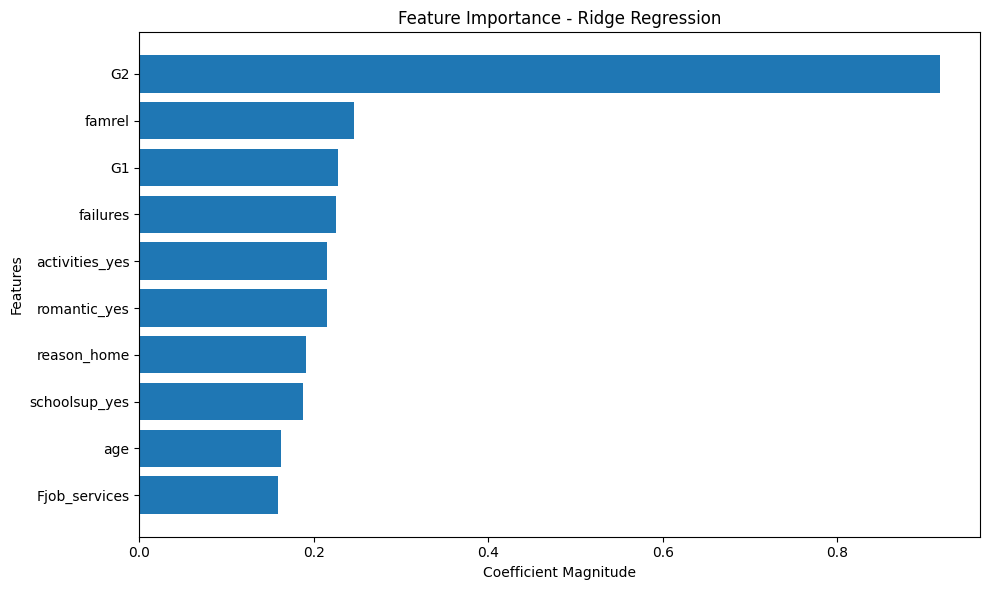

In [109]:
plt.figure(figsize=(10,6))

top10 = coef_df.head(10)

plt.barh(
    top10['Feature'][::-1],
    top10['Coefficient'][::-1]
)

plt.xlabel("Coefficient Magnitude")
plt.ylabel("Features")
plt.title("Feature Importance - Ridge Regression")

plt.tight_layout()

plt.savefig("feature_importance.png")

plt.show()

In [110]:
print(y_train.describe())

count    316.000000
mean      10.325949
std        4.590337
min        0.000000
25%        8.000000
50%       11.000000
75%       13.000000
max       20.000000
Name: G3, dtype: float64


In [111]:
print("Top 3 Important Features")
print(coef_df.head(3))

Top 3 Important Features
   Feature  Coefficient
14      G2     0.917740
6   famrel     0.246465
13      G1     0.227462


print("""
Model Explanation:

1. G2 (Second Period Grade) has the highest influence on final grade prediction.
2. famrel (Family Relationship Quality) contributes to student performance.
3. G1 (First Period Grade) is also a strong predictor of final grade.

These features are the most important factors used by the Ridge Regression model.
""")

In [112]:
def enrich_grade(predicted_score, studytime, absences, failures):

    tips = []

    if studytime < 2:
        tips.append("Increase study time")

    if absences > 5:
        tips.append("Reduce absences")

    if failures > 0:
        tips.append("Seek extra academic support")

    if predicted_score >= 16:
        grade = "Distinction"
    elif predicted_score >= 12:
        grade = "Merit"
    elif predicted_score >= 10:
        grade = "Pass"
    else:
        grade = "Needs Improvement"

    return {
        "Predicted Score": predicted_score,
        "Grade": grade,
        "Tips": tips
    }

In [113]:
result = enrich_grade(
    predicted_score=15,
    studytime=2,
    absences=3,
    failures=0
)

print(result)

{'Predicted Score': 15, 'Grade': 'Merit', 'Tips': []}


In [114]:
samples = [
    {"studytime":4, "absences":1, "failures":0, "predicted_score":18},
    {"studytime":1, "absences":10, "failures":2, "predicted_score":8},
    {"studytime":3, "absences":2, "failures":0, "predicted_score":14},
    {"studytime":2, "absences":5, "failures":1, "predicted_score":11},
    {"studytime":4, "absences":0, "failures":0, "predicted_score":16}
]

In [115]:
for i, sample in enumerate(samples, 1):
    result = enrich_grade(
        sample["predicted_score"],
        sample["studytime"],
        sample["absences"],
        sample["failures"]
    )

    print(f"\nStudent {i}")
    print(result)


Student 1
{'Predicted Score': 18, 'Grade': 'Distinction', 'Tips': []}

Student 2
{'Predicted Score': 8, 'Grade': 'Needs Improvement', 'Tips': ['Increase study time', 'Reduce absences', 'Seek extra academic support']}

Student 3
{'Predicted Score': 14, 'Grade': 'Merit', 'Tips': []}

Student 4
{'Predicted Score': 11, 'Grade': 'Pass', 'Tips': ['Seek extra academic support']}

Student 5
{'Predicted Score': 16, 'Grade': 'Distinction', 'Tips': []}
